In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from scipy.stats import ttest_1samp
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import matplotlib as mpl 
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
# atlas_name = 'glasser'
# atlas_name = 'yeo17'
atlas_name = 'schaefer100'
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
if atlas_name == 'glasser':
    resultsPath = os.path.join(mainResultsPath, f'START_A4_DCBC_pairwise', f'{dataset_name}', atlas_name)
else:
    resultsPath = os.path.join(mainResultsPath, f'START_A4_DCBC_pairwise_resting', f'{dataset_name}', atlas_name)

In [4]:
ROIs = ['PFC', 'visual', 'somatosensory', 'parietal'] 
n_rois = len(ROIs) 
significance_level = 0.05 

In [5]:
cdict = {'red':   ((0.0, 1.0, 1.0),  # Start at white (R=1)
                   (1.0, 1.0, 1.0)), # End at red (R=1)
         'green': ((0.0, 1.0, 1.0),  # Start at white (G=1)
                   (1.0, 0.0, 0.0)), # End at red (G=0)
         'blue':  ((0.0, 1.0, 1.0),  # Start at white (B=1)
                   (1.0, 0.0, 0.0))} # End at red (B=0)

# Create the colormap
cmap = LinearSegmentedColormap('WhiteToRed', cdict)

/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_59672/3320725732.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


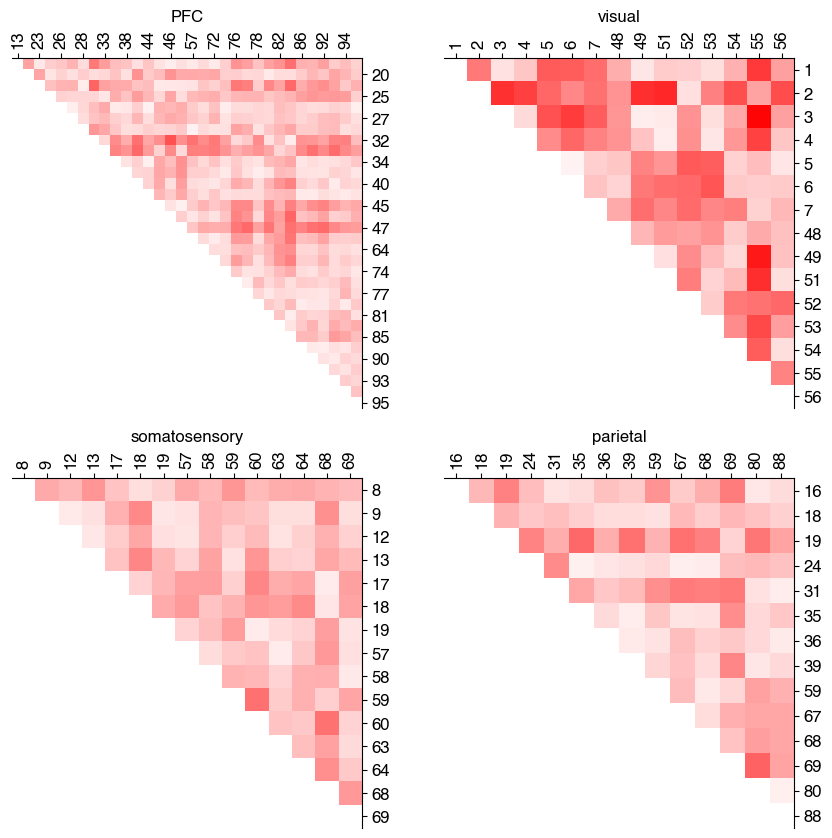

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(full_width, 10), gridspec_kw={'wspace': 0.15, 'hspace': 0.2})

for roiI in np.arange(n_rois):
    PKL_pairwise_dcbc = os.path.join(resultsPath, f'output_{ROIs[roiI]}.pkl')
    with open(PKL_pairwise_dcbc, 'rb') as pf:
        output_pairwise_dcbc = pickle.load(pf)
        dcbc_pairwise = output_pairwise_dcbc['dcbc_pairwise']

    PKL_bayes_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}', atlas_name, f'output_{ROIs[roiI]}.pkl')
    with open(PKL_bayes_parcellation, 'rb') as pf:
        output_bayes_parcellation = pickle.load(pf)
        parcel_names_in_group = output_bayes_parcellation['parcel_names_in_group']

    n_subjects, n_parcels, _ = dcbc_pairwise.shape

    pvals_pairwise = np.inf * np.ones((n_parcels, n_parcels)) 
    dcbc_pairwise[np.logical_or(dcbc_pairwise==np.inf, dcbc_pairwise==-np.inf)] = np.nan 

    for i in np.arange(n_parcels-1):
        for j in np.arange(i+1, n_parcels):
            dcbcs = dcbc_pairwise[:, i, j]            
            ttest_result = ttest_1samp(dcbcs, 0, alternative='greater', nan_policy='omit')
            pvals_pairwise[i, j] = ttest_result.pvalue 
    
    dcbc_pairwise_mean = np.nanmean(dcbc_pairwise, axis=0) 
    dcbc_pairwise_mean[np.logical_and(pvals_pairwise>0.05, pvals_pairwise<np.inf)] = -1 
   
    # fig, ax = plt.subplots() 
    im = ax.ravel()[roiI].imshow(dcbc_pairwise_mean, cmap=cmap, vmin=0, vmax=1)
    # plt.axis('off')
    if ROIs[roiI] == 'PFC' and atlas_name in ['glasser', 'schaefer100']:
        ax.ravel()[roiI].set_xticks(ticks=np.arange(0, n_parcels, 2), labels=[parcel_names_in_group[i] for i in np.arange(0, n_parcels, 2)], rotation=90, fontsize=12) 
        ax.ravel()[roiI].set_yticks(ticks=np.arange(1, n_parcels, 2), labels=[parcel_names_in_group[i] for i in np.arange(1, n_parcels, 2)], rotation=0, fontsize=12) 
    else:
        ax.ravel()[roiI].set_xticks(ticks=np.arange(0, n_parcels), labels=[parcel_names_in_group[i] for i in np.arange(0, n_parcels)], rotation=90, fontsize=12) 
        ax.ravel()[roiI].set_yticks(ticks=np.arange(0, n_parcels), labels=[parcel_names_in_group[i] for i in np.arange(0, n_parcels)], rotation=0, fontsize=12) 

    ax.ravel()[roiI].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, right=True, labelright=True, left=False, labelleft=False) 
    ax.ravel()[roiI].set_title(f'{ROIs[roiI]}', fontsize=12) 
    im.cmap.set_under('blue') 
    ax.ravel()[roiI].spines['left'].set_visible(False)
    ax.ravel()[roiI].spines['bottom'].set_visible(False)
    # cbar = plt.colorbar(im, ticks=[0, 1], ax=ax)  
    # cbar.set_label('mean DCBC', fontsize=12)

plt.tight_layout() 
plt.subplots_adjust(left=0, right=0.95) 

JPG_fig = os.path.join(resultsPath, f'mean_pairwise_dcbc_{atlas_name}.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

In [7]:
# fig, ax = plt.subplots(2, 2, figsize=(full_width, 10), gridspec_kw={'wspace': 0.15, 'hspace': -0.1})

# for roiI in np.arange(n_rois):
#     PKL_pairwise_dcbc = os.path.join(projectPath, 'results', 'START_A4_DCBC_pairwise', f'{dataset_name}', f'output_{ROIs[roiI]}.pkl')
#     with open(PKL_pairwise_dcbc, 'rb') as pf:
#         output_pairwise_dcbc = pickle.load(pf)
#         dcbc_pairwise = output_pairwise_dcbc['dcbc_pairwise']

#     n_subjects, n_parcels, _ = dcbc_pairwise.shape

#     pvals_pairwise = np.inf * np.ones((n_parcels, n_parcels)) 
#     dcbc_pairwise[np.logical_or(dcbc_pairwise==np.inf, dcbc_pairwise==-np.inf)] = np.nan 

#     for i in np.arange(n_parcels-1):
#         for j in np.arange(i+1, n_parcels):
#             dcbcs = dcbc_pairwise[:, i, j]            
#             ttest_result = ttest_1samp(dcbcs, 0, alternative='greater', nan_policy='omit')
#             pvals_pairwise[i, j] = ttest_result.pvalue 
    
#     dcbc_pairwise_mean = np.nanmean(dcbc_pairwise, axis=0) 
#     dcbc_pairwise_mean[np.logical_and(pvals_pairwise>0.05, pvals_pairwise<np.inf)] = -1 
   
#     im = ax.ravel()[roiI].imshow(dcbc_pairwise_mean, cmap=cmap, vmin=0, vmax=1)
#     im.cmap.set_under('blue')  
#     ax.ravel()[roiI].axis('off')
#     ax.ravel()[roiI].set_title(f'{ROIs[roiI]}', fontsize=12)

# plt.tight_layout() 

# JPG_fig = os.path.join(resultsPath, f'mean_pairwise_dcbc_{ROIs[roiI]}.jpg')
# plt.savefig(JPG_fig, dpi=500, format='jpg')

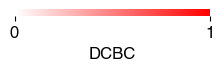

In [8]:
fig, ax = plt.subplots(figsize=(half_width/2, 0.6), layout='constrained')

# cmap = cm.get_cmap('bwr')
norm = mpl.colors.Normalize(vmin=0, vmax=1)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                    cax=ax, orientation='horizontal', label= 'DCBC', ticks=[0, 1], fraction=0.9)
cbar.outline.set_visible(False) 

JPG_fig = os.path.join(resultsPath, 'cbar_pairwise_dcbc.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In [9]:
df = pd.DataFrame(pvals_pairwise)
display(df)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,inf,1.389272e-09,2.047221e-10,1.163584e-11,2.163557e-07,9.167196e-10,1.856250e-09,2.002174e-11,1.083716e-11,2.259496e-09,6.936113e-11,7.956538e-12,1.100167e-07,1.801603e-06
1,inf,inf,1.622692e-08,6.255318e-09,1.802215e-07,9.244539e-08,1.738671e-09,7.513092e-07,2.473871e-06,1.021755e-10,5.101211e-09,1.214755e-08,2.110981e-08,7.351003e-06
2,inf,inf,inf,8.013458e-12,4.248448e-11,1.819211e-10,4.706826e-10,5.278902e-11,2.000736e-09,7.027348e-11,1.516189e-09,1.099589e-07,1.737697e-10,1.595429e-12
3,inf,inf,inf,inf,3.611514e-11,4.256003e-04,1.312527e-09,2.512242e-05,3.548924e-07,2.016508e-05,3.625358e-06,2.367046e-09,8.840859e-10,7.124296e-10
4,inf,inf,inf,inf,inf,1.286371e-11,2.415199e-08,4.210929e-10,3.553243e-11,2.652393e-12,4.367620e-11,4.748502e-13,1.116282e-05,8.676817e-05
5,inf,inf,inf,inf,inf,inf,3.046738e-07,2.139202e-05,5.798689e-08,3.852019e-05,2.066356e-07,2.603486e-10,1.343930e-08,4.249214e-09
6,inf,inf,inf,inf,inf,inf,inf,9.663670e-06,1.590924e-05,9.236159e-13,2.431427e-09,1.431622e-07,1.366711e-05,5.466161e-06
7,inf,inf,inf,inf,inf,inf,inf,inf,1.694713e-08,1.753930e-08,4.026939e-09,3.193116e-10,2.339240e-07,1.674716e-07
8,inf,inf,inf,inf,inf,inf,inf,inf,inf,3.544408e-09,2.095670e-07,1.117646e-07,3.953125e-09,8.054332e-11
9,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,1.646586e-08,2.144265e-08,1.552292e-11,1.301089e-13
